In [1]:
import numpy as np
from jax import config

config.update("jax_enable_x64", True)
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp
from pfaffian_jax import slog_pfaffian
from fgo import FGOState, green_function_from_two
import matplotlib.pyplot as plt

In [ ]:
# TFIM model in terms of Majorana fermions.
# see arXiv:2511.02907 for the details of the mapping between TFIM and Majorana fermions

def gen_tfim(n, J, h, PX=1):
    H = np.zeros([2 * n, 2 * n], dtype=np.complex128)
    idx = np.arange(n)
    H[2 * idx, 2 * idx + 1] = -1j * h

    H[2 * idx[:-1] + 1, 2 * idx[:-1] + 2] = -1j * J
    H[2 * n - 1, 0] = 1j * J * PX
    return 2 * (H - H.T)


def gen_tfim_flip_x(n, J, h, flip_idx, PX=1):
    H = np.zeros([2 * n, 2 * n], dtype=np.complex128)
    idx = np.arange(n)
    H[2 * idx, 2 * idx + 1] = -1j * h
    H[2 * flip_idx, 2 * flip_idx + 1] = 1j * h

    H[2 * idx[:-1] + 1, 2 * idx[:-1] + 2] = -1j * J
    H[2 * n - 1, 0] = 1j * J * PX
    return 2 * (H - H.T)

In [3]:
# \ket{+} state in Majorana representation.
def gen_plus_jax(n):
    N = 2 * n
    H = jnp.zeros((N, N), dtype=jnp.complex128)
    idx = 2 * jnp.arange(n)
    H = H.at[idx, idx + 1].set(1.0j)
    Hsym = H - H.T
    _, v = jnp.linalg.eigh(Hsym)
    return v[:, :n]


# ket{-} state in Majorana representation. X_i = 1, X_i = -1 for the last site.
def gen_minus_jax(n):
    N = 2 * n
    H = jnp.zeros((N, N), dtype=jnp.complex128)
    idx = 2 * jnp.arange(n - 1)
    H = H.at[idx, idx + 1].set(1.0j)
    H = H.at[2 * (n - 1), 2 * (n - 1) + 1].set(-1.0j)
    Hsym = H - H.T
    _, v = jnp.linalg.eigh(Hsym)
    return v[:, :n]


# ZZ stablizer state in Majorana representation. zz is the eigenvalue of Z_i Z_{i+1}.
def gen_v_from_zz(zz, PX=1):
    zz = jnp.asarray(zz)
    n = zz.shape[-1]
    N = 2 * n

    sgn = jnp.sign(zz)
    sgn = sgn.at[..., -1].set(-PX * sgn[..., -1])  # parity convention

    norm = 1.0 / jnp.sqrt(2.0)
    top = (-1j * sgn) * norm
    bot = (1.0 + 0j) * norm

    a_idx = 2 * jnp.arange(n) + 1  # (n,)
    b_idx = (2 * jnp.arange(n) + 2) % N
    col_idx = jnp.arange(n)

    batch_shape = zz.shape[:-1]
    v = jnp.zeros(batch_shape + (N, n), dtype=jnp.complex128)
    v = v.at[..., a_idx, col_idx].set(top)
    v = v.at[..., b_idx, col_idx].set(bot)
    return v


# \ket{s} + PX\ket{-s} state in Majorana representation.
def v_from_s(s, PX=1):
    zz_val = s * jnp.roll(s, -1, axis=-1)
    return gen_v_from_zz(zz_val, PX)

In [4]:
# calculate the total Z magnetization for the state exp(-iHt) |s0> where |s0> is a product state in the Z basis.
# s0_i(<s0+|expih(x_i->-x_i)t exp-iht |s0+> + <s0-|expih(x_i->-x_i)t exp-iht |s0->)
def sz_peaked_state(n, J, h, t, s0):
    s0_plus = v_from_s(s0, PX=1)
    s0_minus = v_from_s(s0, PX=-1)
    fgo_s0_plus = FGOState(0.0, s0_plus, s0_plus)
    fgo_s0_minus = FGOState(0.0, s0_minus, s0_minus)

    H_plus = -1.0j * t * gen_tfim(n, J, h, PX=1)
    H_minus = -1.0j * t * gen_tfim(n, J, h, PX=-1)
    fgo_expmih_plus = fgo_s0_plus.apply_quadratic(H_plus)
    fgo_expmih_minus = fgo_s0_minus.apply_quadratic(H_minus)

    total_z = 0.0
    for i in range(n):
        H_flip_plus = 1.0j * t * gen_tfim_flip_x(n, J, h, i, PX=1)
        H_flip_minus = 1.0j * t * gen_tfim_flip_x(n, J, h, i, PX=-1)

        fgo_plus = fgo_expmih_plus.apply_quadratic(H_flip_plus)
        fgo_minus = fgo_expmih_minus.apply_quadratic(H_flip_minus)

        total_z += s0[i] / 2 * (jnp.exp(fgo_plus.logeta) + jnp.exp(fgo_minus.logeta))

    return jnp.real(total_z)

t=0.000
t=0.250


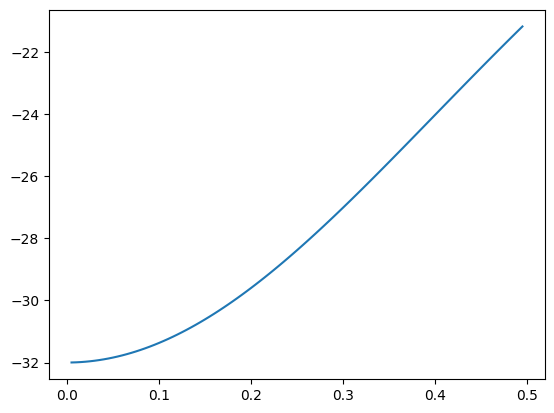

In [5]:
J = 1.0
h = 1.0
N = 32
T = 0.5
tlist = np.arange(0, T, T/100)

s0 = jnp.array([-1] * N)
total_z = []
for i, t in enumerate(tlist):
    if i % 50 == 0:
        print(f"t={t:.3f}")
    total_z.append(sz_peaked_state(N, J, h, t, s0))
plt.plot(tlist, total_z, "-")

In [6]:
import os
save_path = f"../data/TFIM_exact_Z/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
np.save(save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", tlist)
np.save(save_path + f"exactZ_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", total_z )

In [8]:
def expiHt(H, t):
    e, v = jnp.linalg.eigh(H)
    phase = jnp.exp(1.0j * t * e)
    return (v * phase) @ v.conj().T

def gen_mask_for_PZ(N):
    assert N % 2 == 0
    mask = [False] * 2 * N
    for i in range(N // 2):
        mask[4 * i + 1] = True
        mask[4 * i + 2] = True
    return mask

# calculate the Z-parity given green function 
def evaluate_PZ(G, N):
    mask = gen_mask_for_PZ(N)
    s, logpf = slog_pfaffian(G[mask, :][:, mask])
    return jnp.exp(logpf) * (-1.0j) ** (N // 2) * s

In [9]:
# calculate the Z-parity for the state exp(-iHt) |even>
def parity_Z(N, J, h, t):
    plus_state = gen_plus_jax(N)
    H_J_mh = gen_tfim(N, J, -h)
    H_J_h = gen_tfim(N, J, h)

    fgo = FGOState(0.0, plus_state, plus_state)
    fgo = fgo.apply_quadratic(1.0j * t * H_J_h)
    fgo = fgo.apply_quadratic(-1.0j * t * H_J_mh)
    term0 = np.real(np.exp(fgo.logeta))

    state1 = expiHt(H_J_mh, -t) @ plus_state
    state2 = expiHt(H_J_h, -t) @ plus_state
    G1 = green_function_from_two(state1, state1)
    G2 = green_function_from_two(state2, state2)
    term1 = 0.5 * evaluate_PZ(G1, N)
    term2 = 0.5 * evaluate_PZ(G2, N)

    return np.real(term0 + term1 + term2)

Text(0.5, 0, 't')

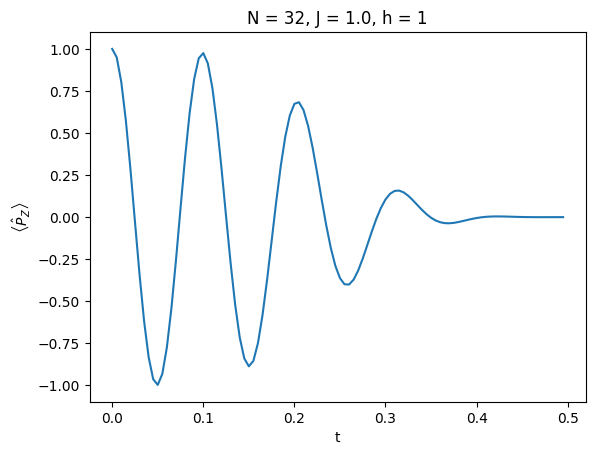

In [11]:
J = 1.0
h = 1
N = 32
T = 0.5
tlist = np.arange(0.0, T, T/100)
pZlist = [parity_Z(N, J, h, t) for t in tlist]
plt.title(f"N = {N}, J = {J}, h = {h}")
plt.plot(tlist, pZlist)
plt.ylabel(r"$\left<\hat P_Z\right>$")
plt.xlabel(r"t")

In [10]:
import os
save_path = f"../data/TFIM_exact_parity/"
if not os.path.exists(save_path):
    os.makedirs(save_path)
np.save(save_path + f"times_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", tlist)
np.save(save_path + f"parityZ_{N}_h{h:1.2f}_J{J:1.2f}_T{T:1.2f}.npy", pZlist)

In [34]:
from fgo import expH_times_fgo_state

In [35]:
def all_spin_configs(N):
    nstates = 2**N
    ints = jnp.arange(nstates, dtype=jnp.uint32)

    # Extract bits
    bits = (ints[:, None] >> jnp.arange(N)) & 1

    # Convert {0,1} → {-1,+1}
    spins = 2 * bits - 1
    return spins.astype(jnp.float64)

In [36]:
# Tr(|+><s+|exp(H)|s0+><+|) + Tr(|-><s-|exp(H)|s0-><-|)
def log_amplitude_peak(N, H_plus, H_minus, s0, s):
    # const for N
    plus_state = gen_plus_jax(N)
    minus_state = gen_minus_jax(N)

    s0_plus = v_from_s(s0, PX=1)
    s0_minus = v_from_s(s0, PX=-1)

    fgo_s0_plus = FGOState(0.0, s0_plus, plus_state)
    fgo_s0_minus = FGOState(
        jnp.log(s0[-1].astype(jnp.complex128)), s0_minus, minus_state
    )

    fgo_expH_s0_plus = fgo_s0_plus.apply_quadratic(H_plus)
    fgo_expH_s0_minus = fgo_s0_minus.apply_quadratic(H_minus)

    s_plus = v_from_s(s, PX=1)
    s_minus = v_from_s(s, PX=-1)
    fgo_plus_s = FGOState(0.0, plus_state, s_plus)
    fgo_minus_s = FGOState(jnp.log(s[-1].astype(jnp.complex128)), minus_state, s_minus)

    fgo_plus_total = fgo_plus_s @ fgo_expH_s0_plus
    fgo_minus_total = fgo_minus_s @ fgo_expH_s0_minus

    logamp = logsumexp(
        jnp.stack([fgo_plus_total.logeta, fgo_minus_total.logeta], axis=0), axis=0
    )
    return logamp


def full_wavefunction_peaked_state(N, J, h, t, s0):
    H1 = gen_tfim(N, J, h, PX=1) * 1j * t
    H2 = gen_tfim(N, J, h, PX=-1) * 1j * t
    spins = all_spin_configs(N)
    amp_fn = lambda s: log_amplitude_peak(N, H1, H2, s0, s)
    logpsi = jax.vmap(amp_fn)(spins)
    return spins, jnp.exp(logpsi)


def sz_peaked_state_from_wavefunction(N, J, h, t, s0):
    spins, psi = full_wavefunction_peaked_state(N, J, h, t, s0)
    prob = jnp.abs(psi) ** 2
    sz = jnp.sum(prob * jnp.sum(spins, axis=-1)) / jnp.sum(prob)
    return sz

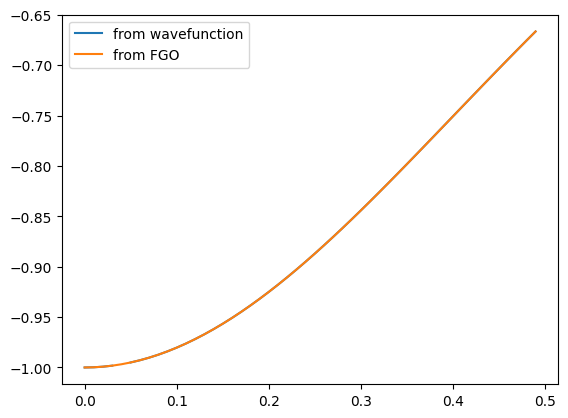

In [37]:
tlist = np.arange(0, 0.5, 0.01)
n = 4
J = 1.0
h = 1.0
s0 = jnp.array([-1] * n)
plt.plot(
    tlist,
    [sz_peaked_state_from_wavefunction(n, J, h, t, s0) / n for t in tlist],
    label="from wavefunction",
)
plt.plot(tlist, [sz_peaked_state(n, J, h, t, s0) / n for t in tlist], label="from FGO")
plt.legend()

In [38]:
def logamp_parity(H1, H2, s, plus_state):
    v_s_plus = v_from_s(s, PX=1)
    fgs_plus_s = (0.0, plus_state, v_s_plus)
    fgo_1 = expH_times_fgo_state(H1, fgs_plus_s)
    fgo_2 = expH_times_fgo_state(H2, fgs_plus_s)
    s_prod = jnp.prod(s, axis=-1).astype(jnp.complex128)
    logamp = logsumexp(
        jnp.stack([fgo_1[0], jnp.log(s_prod) + fgo_2[0]], axis=0), axis=0
    )
    return logamp


def full_wavefunction_parity_problem(N, J, h, t):
    H1 = gen_tfim(N, J, h) * 1j * t
    H2 = gen_tfim(N, J, -h) * 1j * t
    plus_state = gen_plus_jax(N)
    spins = all_spin_configs(N)

    amp_fn = lambda s: logamp_parity(H1, H2, s, plus_state)
    logpsi = jax.vmap(amp_fn)(spins)
    psi = jnp.exp(logpsi)

    return spins, psi


def parity_from_wavefunction(N, J, h, t):
    spins, psi = full_wavefunction_parity_problem(N, J, h, t)
    prob = jnp.abs(psi) ** 2
    parity = jnp.sum(prob * jnp.prod(spins, axis=-1)) / jnp.sum(prob)
    return parity

In [19]:
v_s_plus = v_from_s(jnp.array([1]*N), PX=1)
v_plus = gen_plus_jax(N)
G = green_function_from_two(v_s_plus, v_plus)

In [20]:
G

Array([[ 0.+0.j,  0.+1.j,  1.+0.j, ...,  0.+1.j,  1.+0.j,  0.+1.j],
       [ 0.-1.j,  0.+0.j,  0.+1.j, ..., -1.+0.j,  0.+1.j, -1.+0.j],
       [-1.+0.j,  0.-1.j,  0.+0.j, ...,  0.+1.j,  1.+0.j,  0.+1.j],
       ...,
       [ 0.-1.j,  1.+0.j,  0.-1.j, ...,  0.+0.j,  0.+1.j, -1.+0.j],
       [-1.+0.j,  0.-1.j, -1.+0.j, ...,  0.-1.j,  0.+0.j,  0.+1.j],
       [ 0.-1.j,  1.+0.j,  0.-1.j, ...,  1.+0.j,  0.-1.j,  0.+0.j]],      dtype=complex128)

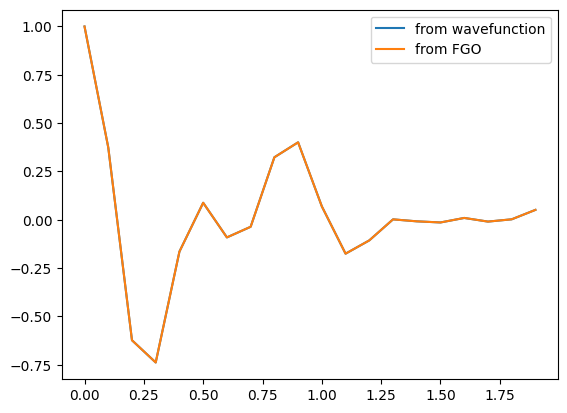

In [39]:
tlist = np.arange(0, 2.0, 0.1)
plt.plot(
    tlist,
    [parity_from_wavefunction(6, 1.0, 1.0, t) for t in tlist],
    label="from wavefunction",
)
plt.plot(tlist, [parity_Z(6, 1.0, 1.0, t) for t in tlist], label="from FGO")
plt.legend()

In [11]:
np.block([[G, -IN], [IN, u@vT - vT.T @ u.T]])

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 12 and the array at index 1 has size 6

In [90]:
N= 8
m = 4
G = np.random.uniform(-1,1,[N,N])
G = G - G.T
u = np.random.uniform(0,1,[N, m])
vT = np.random.uniform(0,1,[m, N])
IN = np.eye(vT.shape[1])
print(slog_pfaffian(np.block([[G, -IN], [IN, u@vT - vT.T @ u.T]])))
print(slog_pfaffian(np.block([[u.T @ G @ u, -np.eye(vT.shape[0]) + u.T @ G @ vT.T], 
                                  [np.eye(vT.shape[0]) + vT @ G @ u, vT @ G @ vT.T]])))

(Array(1., dtype=float64), Array(-0.32814889, dtype=float64))
(Array(1., dtype=float64), Array(-0.32814889, dtype=float64))


In [ ]:
M = np.block([[G, -IN],
              [IN, u@vT - vT.T@u.T]])
K = np.eye(vT.shape[0]) + vT @ G @ u

detM = np.linalg.det(M)
detK = np.linalg.det(K)

print("det(M) =", detM)
print("det(K)^2 =", detK**2)
print("ratio det(M)/det(K)^2 =", detM/(detK**2))

det(M) = 0.013721129591675745
det(K)^2 = 3.926162134469443
ratio det(M)/det(K)^2 = 0.0034947944383682296


In [15]:
v_from_s(jnp.array([1, -1, 1, -1]), PX=1)

Array([[0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.70710678+0.j        ],
       [0.        +0.70710678j, 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.70710678+0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.70710678j,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.70710678+0.j        ,
        0.        +0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.70710678j, 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.70710678+0.j        , 0.        +0.j        ],
       [0.        +0.j        , 0.        +0.j        ,
        0.        +0.j        , 0.        -0.70710678j]],      dtype=complex128)